**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO *DETECT FEATURE DRIFT BY COMPARING TRAINING AND PRODUCTION DATA DISTRIBUTIONS*. 🧠📊📉**

This script demonstrates how to detect **feature drift**, a common production ML issue where the distribution of incoming data changes over time compared to training data.

Feature drift can silently degrade model performance — even if your model was originally accurate.

---

## **📦 Import Required Libraries**

We’ll use pandas for data handling and scipy for statistical comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

---

## **🧩 Create Training Data (Reference Data)**

We simulate training data distribution.

In [2]:
np.random.seed(42)

train_data = pd.DataFrame({
    "age": np.random.normal(35, 10, 1000),
    "income": np.random.normal(50000, 15000, 1000)
})

---

## **🚀 Simulate Production Data (Drifted Data)**

We introduce drift by shifting the distributions.

In [3]:
production_data = pd.DataFrame({
    "age": np.random.normal(42, 12, 1000),      # shifted mean
    "income": np.random.normal(65000, 20000, 1000)
})

---

## **📊 Visualize Distribution Shift**

We compare feature distributions visually.

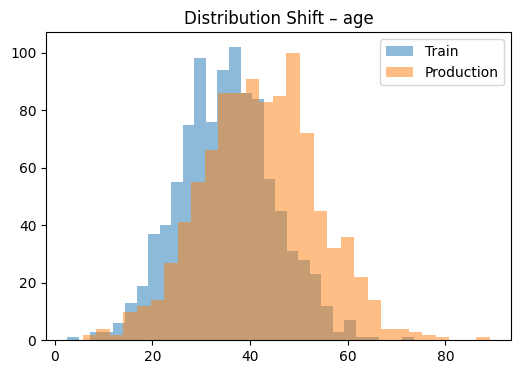

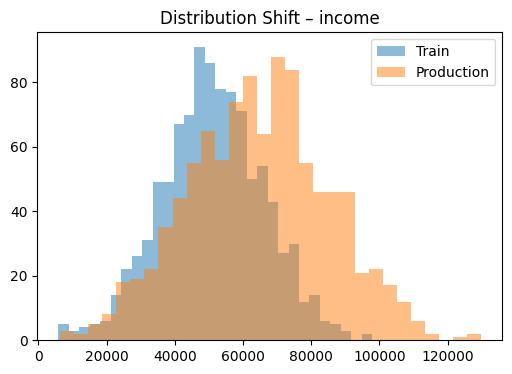

In [4]:
for col in train_data.columns:
    plt.figure(figsize=(6, 4))

    plt.hist(train_data[col], bins=30, alpha=0.5, label="Train")
    plt.hist(production_data[col], bins=30, alpha=0.5, label="Production")

    plt.title(f"Distribution Shift – {col}")
    plt.legend()
    plt.show()

This gives an intuitive understanding of how the data has changed.

---

## **🔍 Statistical Drift Detection (KS Test)**

We use the **Kolmogorov–Smirnov test** to quantify drift.

In [5]:
drift_results = {}

for col in train_data.columns:
    stat, p_value = ks_2samp(train_data[col], production_data[col])

    drift_results[col] = {
        "ks_stat": stat,
        "p_value": p_value
    }

    print(f"{col} → KS Stat: {stat:.4f}, p-value: {p_value:.4f}")

age → KS Stat: 0.2750, p-value: 0.0000
income → KS Stat: 0.3320, p-value: 0.0000


---

## **🚨 Interpret Drift Results**

We define a threshold to flag drift.

In [6]:
for col, values in drift_results.items():
    if values["p_value"] < 0.05:
        print(f"⚠️ Drift detected in feature: {col}")
    else:
        print(f"✅ No significant drift in feature: {col}")

⚠️ Drift detected in feature: age
⚠️ Drift detected in feature: income


- Low p-value → distributions are different → drift detected
- High p-value → distributions are similar

---

## **🔍 Why Feature Drift Matters**

Feature drift can lead to:

- degraded model performance
- incorrect predictions
- business risk
- unreliable decision-making

Drift detection is a key part of **ML monitoring systems**.

---

## **🧠 Key Takeaways**

1. Feature drift occurs when data distribution changes over time.
2. It can silently reduce model performance.
3. Visual plots help identify drift intuitively.
4. Statistical tests like KS test quantify drift.
5. Essential for production ML monitoring systems.

---

## **Conclusion**

Feature drift detection is a fundamental step in maintaining reliable machine learning systems in production. By continuously comparing training data with incoming data, we can detect shifts early and take corrective action — such as retraining models or updating pipelines.

This strengthens the **Production ML** track within the **AI with Python** series.

---